# Flood · Solar — M2 coupling: sample the M1 hazard fields at the solar footprint (all three sub-perils)

**Peril:** Flood · **Asset:** Solar · **Layer:** M2 (coupling) · sub-perils `riverine` + `pluvial` + `coastal`

**Magnitude metric:** flood **depth (ft above ground)** at the footprint — riverine indexed by annual return period
(10–500-yr), pluvial by return period, coastal surge by hurricane category, per storm. M2 produces, per sub-peril,
an `exposure_fraction` (areal inundated share of the polygon) and a `conditional_depth` (mean depth given flooded).

**Data source:** the shared M1 field manifests (riverine BLE depth grids, pluvial Atlas 14 → SCS-CN runoff, coastal
RAFT storm catalog), plus **1 m lidar** DEMs from The National Map (TNM) for pluvial ponding and **NOAA SLOSH MOM**
(high-tide) inundation tiles for coastal surge. USGS flow-frequency `Q(T)` from the riverine M1 anchors the
densification.

**What this notebook does:** for each sub-peril it samples the M1 hazard field at the solar polygon and reduces it
to the `(exposure_fraction, conditional_depth)` contract M3 consumes. **Riverine** = areal sampling of the
full-resolution BLE depth field over the footprint ([JD-FL-18](../../../../docs/plans/flood/decisions.md)), with the
lower return periods densified from the M1 flow-frequency `Q(T)` rating
([JD-FL-8](../../../../docs/plans/flood/decisions.md)). **Pluvial** = pour the M1 runoff `Q` over the footprint's 1 m-
lidar closed depressions → ponding fraction `f` and a depression-capped wet-cell depth. **Coastal** = areal SLOSH MOM
surge per hurricane category, per storm, `event_family_id`-stamped. Both inland sub-perils read the shared M1 field
manifests and filter to this asset's solar sites; per-subsystem height conditioning is M3's job.

In [1]:
import json, math, os, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import requests, tifffile, pyproj
import shapely.vectorized as sv
from shapely import wkt
from shapely.ops import transform
from matplotlib.path import Path as MPath
from skimage.morphology import reconstruction

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"
FT_M = 0.3048; IN_M = 0.0254

# footprint geometry (from M0) to mask the field against
_geo = {s["eia"]: s for s in json.loads((OUT / "flood_solar_m0_dem_context.json").read_text())["sites"]}

## 1 · Riverine — sample the M1 depth field areally over the footprint

In [2]:
rman = json.loads((OUT / "flood_riverine_m1_catalog_manifest.json").read_text())   # shared riverine FIELD manifest (all sites, method-tagged)
DENSE_RP = [10, 25, 50]

def reduce_field(npz_path, geom):
    """Areal reduction of the depth field over the footprint → (inund_frac, conditional_depth_m, depth_max_m).
    This is M2's job (JD-FL-19): mask the field to the asset, then summarise."""
    d = np.load(ROOT / npz_path); grid = d["depth_ft"]; xmin, ymin, xmax, ymax = d["extent"]
    H, W = grid.shape
    XX, YY = np.meshgrid(np.linspace(xmin, xmax, W), np.linspace(ymax, ymin, H))
    infp = sv.contains(geom, XX, YY)
    if not infp.any():
        return 0.0, 0.0, 0.0
    wet = infp & (grid > 0)
    frac = float(wet.sum()) / float(infp.sum())
    dwet = float(grid[wet].mean()) * FT_M if wet.any() else 0.0
    dmax = float(grid[infp].max()) * FT_M
    return round(frac, 3), round(dwet, 3), round(dmax, 3)

def extent_fraction(npz_path, geom):
    d = np.load(ROOT / npz_path); mask = d["mask"]; xmin, ymin, xmax, ymax = d["extent"]
    H, W = mask.shape
    XX, YY = np.meshgrid(np.linspace(xmin, xmax, W), np.linspace(ymax, ymin, H))
    infp = sv.contains(geom, XX, YY)
    return round(float((infp & (mask > 0)).sum()) / float(infp.sum()), 3) if infp.any() else 0.0

riv_rows = []
red = {}   # name -> {rp: (frac, dwet, dmax)} for the densification anchors
for fm in rman["field"]:
    if fm["method"] != "ble_image":            # this asset's sites only (solar = BLE-image; JD-FL-19)
        continue
    geom = wkt.loads(_geo[fm["eia"]]["boundary_wkt"])
    red[fm["name"]] = {}
    for rp in (100, 500):
        frac, dwet, dmax = reduce_field(fm["rasters"][str(rp)]["path"], geom)
        red[fm["name"]][rp] = (frac, dwet, dmax)
        riv_rows.append({"sub_peril": "riverine", "name": fm["name"], "role": fm["role"], "rp_years": rp,
                         "aep": round(1/rp, 4), "exposure_fraction": frac, "conditional_depth_m": dwet, "depth_max_m": dmax})
    f10 = extent_fraction(fm["rasters"]["10ext"]["path"], geom)
    red[fm["name"]]["f10"] = f10

# densify lower RPs at the proving site (JD-FL-8) — Q(T) from M1, anchored to the M2-reduced BLE depths
ff = rman["flow_frequency"]
for nm, prov in ff.items():
    Q = {int(k): v for k, v in prov["Q_cfs"].items()}; Q500 = prov["Q500_cfs_extrap"]
    d100, d500 = red[nm][100][1], red[nm][500][1]; f10, f100 = red[nm]["f10"], red[nm][100][0]
    p_exp = math.log(d500 / d100) / math.log(Q500 / Q[100])
    frac_log = lambda rp: f10 + (f100 - f10) * (math.log(rp) - math.log(10)) / (math.log(100) - math.log(10))
    for rp in DENSE_RP:
        dep = round(d100 * (Q[rp] / Q[100]) ** p_exp, 3); fr = round(f10 if rp == 10 else frac_log(rp), 3)
        riv_rows.append({"sub_peril": "riverine", "name": nm, "role": "proving (high-flood)", "rp_years": rp,
                         "aep": round(1/rp, 4), "exposure_fraction": fr, "conditional_depth_m": dep, "depth_max_m": dep})
    print(f"densified {nm}: rating p={p_exp:.3f}, 10yr depth {round(d100*(Q[10]/Q[100])**p_exp,3)/FT_M:.2f} ft (frac {f10})")

riv = pd.DataFrame(riv_rows)
print("\nriverine coupling (M2-reduced from the field, full-resolution JD-FL-18):")
print(riv[riv.rp_years.isin([100,500])][["name","rp_years","exposure_fraction","conditional_depth_m"]].to_string(index=False))

/var/folders/l0/yb95shf55vjcxbpd5m57fwxc0000gn/T/ipykernel_65895/2961365552.py:10: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  infp = sv.contains(geom, XX, YY)
/var/folders/l0/yb95shf55vjcxbpd5m57fwxc0000gn/T/ipykernel_65895/2961365552.py:23: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  infp = sv.contains(geom, XX, YY)


densified Elizabeth Solar Plant: rating p=0.630, 10yr depth 1.01 ft (frac 0.102)
densified LA3 West Baton Rouge Solar Facility: rating p=-0.154, 10yr depth 1.28 ft (frac 0.521)

riverine coupling (M2-reduced from the field, full-resolution JD-FL-18):
                               name  rp_years  exposure_fraction  conditional_depth_m
               Hayhurst Texas Solar       100              0.087                0.159
               Hayhurst Texas Solar       500              0.150                0.183
              Elizabeth Solar Plant       100              0.177                0.433
              Elizabeth Solar Plant       500              0.218                0.532
LA3 West Baton Rouge Solar Facility       100              0.509                0.355
LA3 West Baton Rouge Solar Facility       500              0.953                0.335


## 2 · Pluvial — pour the M1 runoff `Q` over the footprint's 1 m-lidar depressions

The ponding fraction `f` (low-lying share of the pad, from a 1 m-lidar closed-depression analysis) and the ponding
math are per-asset terrain, so they live in M2 (per JD-FL-19). Footprint-average ponding = `r·Q`; wet-cell depth =
`r·Q/f`, capped at the lidar depression depth. `f` is the pluvial exposure (AFL-P2, lidar-grounded).

In [3]:
GDALBIN = Path(sys.executable).parent
_GENV = dict(os.environ, GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR")
_LCACHE = OUT / "raw" / "lidar"; _LCACHE.mkdir(parents=True, exist_ok=True)
FALLBACK_F, FALLBACK_DCAP_M, POND_THRESH_M, RETENTION = 0.10, 0.5, 0.05, 0.5

def _utm_epsg(lon): return 26900 + int((lon + 180) / 6) + 1

def _tnm_1m_tiles(bounds):
    mnx, mny, mxx, mxy = bounds
    r = requests.get("https://tnmaccess.nationalmap.gov/api/v1/products",
                     params={"datasets": "Digital Elevation Model (DEM) 1 meter",
                             "bbox": f"{mnx},{mny},{mxx},{mxy}", "outputFormat": "JSON", "max": 20}, timeout=60)
    return [it["downloadURL"] for it in r.json().get("items", [])]

def lidar_ponding_fraction(eia, footprint, lon, default_f=FALLBACK_F, thr=POND_THRESH_M):
    """Terrain-derived ponding fraction from 1 m lidar (closed-depression share); fallback if lidar absent."""
    tif = _LCACHE / f"{eia}_1m.tif"
    if not tif.exists():
        tiles = _tnm_1m_tiles(footprint.bounds)
        if not tiles:
            return default_f, FALLBACK_DCAP_M, {"f_source": "fallback — no 1 m lidar coverage", "f": default_f}
        epsg = _utm_epsg(lon)
        g = transform(pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True).transform, footprint)
        mnx, mny, mxx, mxy = [int(round(b)) for b in g.bounds]
        vrt = _LCACHE / f"{eia}.vrt"; lst = _LCACHE / f"{eia}.txt"
        lst.write_text("\n".join("/vsicurl/" + u for u in tiles))
        subprocess.run([str(GDALBIN / "gdalbuildvrt"), "-q", "-input_file_list", str(lst), str(vrt)], env=_GENV, check=True, capture_output=True)
        subprocess.run([str(GDALBIN / "gdalwarp"), "-q", "-overwrite", "-t_srs", f"EPSG:{epsg}",
                        "-te", str(mnx), str(mny), str(mxx), str(mxy), "-tr", "1", "1", "-r", "bilinear",
                        "-dstnodata", "-9999", "-co", "COMPRESS=DEFLATE", str(vrt), str(tif)], env=_GENV, check=True, capture_output=True)
        (tif.with_suffix(".meta")).write_text(json.dumps({"epsg": epsg, "te": [mnx, mny, mxx, mxy]}))
    meta = json.loads((tif.with_suffix(".meta")).read_text()); mnx, mny, mxx, mxy = meta["te"]
    g = transform(pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{meta['epsg']}", always_xy=True).transform, footprint)
    dem_a = tifffile.imread(str(tif)).astype("f8"); nl, ns = dem_a.shape
    xs = mnx + (np.arange(ns) + 0.5); ys = mxy - (np.arange(nl) + 0.5)
    X, Y = np.meshgrid(xs, ys)
    inside = MPath(np.array(g.exterior.coords)).contains_points(np.column_stack([X.ravel(), Y.ravel()])).reshape(nl, ns)
    valid = inside & (dem_a > -9990) & np.isfinite(dem_a)
    cover = valid.sum() / max(inside.sum(), 1)
    if cover < 0.5:
        return default_f, FALLBACK_DCAP_M, {"f_source": f"fallback — coverage {cover:.0%} < 50%", "f": default_f}
    work = dem_a.copy(); work[~valid] = dem_a[valid].min() - 100.0
    mk = np.full_like(work, work.max())
    mk[0, :] = work[0, :]; mk[-1, :] = work[-1, :]; mk[:, 0] = work[:, 0]; mk[:, -1] = work[:, -1]
    depth = reconstruction(mk, work, method="erosion") - work
    pond = depth[(depth > thr) & valid]
    f = len(pond) / valid.sum(); d_cap = float(pond.mean()) if len(pond) else FALLBACK_DCAP_M
    return (round(max(f, 0.005), 3), round(d_cap, 3),
            {"f_source": f"1 m lidar closed-depression (≥{thr} m, {cover:.0%} cover)", "depression_depth_cap_m": round(d_cap, 3)})

_sites = {s["name"]: s for s in json.loads((OUT / "flood_solar_m0_sites.json").read_text())["sites"]}
pman = json.loads((OUT / "flood_pluvial_m1_catalog_manifest.json").read_text())   # shared pluvial FIELD manifest (all sites)
fcache, plu_rows = {}, []
for r in pman["field"]:
    if r["asset"] != "solar":                  # this asset's sites only
        continue
    nm = r["name"]; s = _sites[nm]
    if nm not in fcache:
        fcache[nm] = lidar_ponding_fraction(s["eia"], wkt.loads(_geo[s["eia"]]["boundary_wkt"]), s["lon"])
        print(f"  {nm:24s} f={fcache[nm][0]:.3f}, depth-cap={fcache[nm][1]:.2f} m ({fcache[nm][2]['f_source']})")
    f, dcap, _ = fcache[nm]
    cond = min(RETENTION * r["runoff_m"] / f, dcap) if f > 0 else 0.0
    plu_rows.append({"sub_peril": "pluvial", "name": nm, "role": r["role"], "rp_years": r["rp_years"], "aep": r["aep"],
                     "exposure_fraction": round(f, 3), "conditional_depth_m": round(cond, 3), "depth_max_m": round(cond, 3)})
plu = pd.DataFrame(plu_rows)

coup = pd.concat([riv, plu], ignore_index=True)
coup["coupling_type"] = "site_conditioned"

  Hayhurst Texas Solar     f=0.005, depth-cap=0.29 m (1 m lidar closed-depression (≥0.05 m, 100% cover))


  Elizabeth Solar Plant    f=0.016, depth-cap=0.10 m (1 m lidar closed-depression (≥0.05 m, 100% cover))


  LA3 West Baton Rouge Solar Facility f=0.026, depth-cap=0.33 m (1 m lidar closed-depression (≥0.05 m, 100% cover))


## 3 · Coastal — areal SLOSH MOM surge over the footprint, per storm

Per-category footprint sampling of the SLOSH MOM surge for every coastal-exposed solar site (Discovery + the
all-three **LA3**). The SLOSH LZW tiles are read via a GDAL-decompressed (DEFLATE, cached) copy so this runs in the
hazard env (no `imagecodecs`). Event-based (per storm), `event_family_id`-stamped — the M4 coastal compound input.

In [4]:
from shapely.geometry import Point
SLOSH = OUT / "raw" / "slosh" / "US_SLOSH_MOM_Inundation_v2"
_SLOSH_DEFL = OUT / "raw" / "slosh" / "deflate"; _SLOSH_DEFL.mkdir(parents=True, exist_ok=True)
COASTAL_DEPTH_SOURCE = "SLOSH_MOM_US_v2_HighTide"   # JD-FL-14 tag

def _slosh_tfw(c):
    v = [float(x) for x in (SLOSH / f"US_Category{c}_MOM_Inundation_HighTide.tfw").read_text().split()]
    return v[0], v[3], v[4], v[5]
def _slosh_arr(c):
    src = SLOSH / f"US_Category{c}_MOM_Inundation_HighTide.tif"; defl = _SLOSH_DEFL / f"cat{c}_deflate.tif"
    if not defl.exists():
        subprocess.run([str(GDALBIN / "gdal_translate"), "-q", "-co", "COMPRESS=DEFLATE", str(src), str(defl)],
                       env=_GENV, check=True, capture_output=True)
    return tifffile.imread(str(defl))
def footprint_depth(c, poly):
    """Areal SLOSH MOM Cat-c over the polygon → (footprint-mean ft, inundated fraction, max ft). 0/255 = dry."""
    px, py, ox, oy = _slosh_tfw(c); arr = _slosh_arr(c); minx, miny, maxx, maxy = poly.bounds
    c0, c1 = int((minx - ox) / px), int((maxx - ox) / px); r0, r1 = int((maxy - oy) / py), int((miny - oy) / py)
    depths = []
    for row in range(max(r0, 0), min(r1, arr.shape[0] - 1) + 1):
        for col in range(max(c0, 0), min(c1, arr.shape[1] - 1) + 1):
            lon, lat = ox + (col + 0.5) * px, oy + (row + 0.5) * py
            if poly.contains(Point(lon, lat)):
                v = int(arr[row, col]); depths.append(0.0 if v in (0, 255) else v - 0.5)
    del arr
    if not depths: return 0.0, 0.0, 0.0
    dd = np.array(depths); return float(dd.mean()), float((dd > 0).mean()), float(dd.max())

cman = json.loads((OUT / "flood_coastal_m1_catalog_manifest.json").read_text())
coastal_solar = [c for c in cman["sites"] if c["asset"] == "solar" and c["exposed"]]
coastal_summ = []
for cs in coastal_solar:
    cslug = cs["slug"]; poly = wkt.loads(cs["boundary_wkt"]); scat = pd.read_parquet(OUT / cs["catalog_parquet"])
    dbc = {}
    for c in range(1, 6):
        m_ft, frac, mx = footprint_depth(c, poly); dbc[c] = {"mean_ft": round(m_ft, 2), "inund_frac": round(frac, 3), "max_ft": round(mx, 2)}
    scat["surge_depth_ft"] = scat["category"].map(lambda c: dbc.get(int(c), {}).get("mean_ft", 0.0))
    scat["exposure_fraction"] = scat["category"].map(lambda c: dbc.get(int(c), {}).get("inund_frac", 0.0))
    scat["conditional_depth_ft"] = np.where(scat["exposure_fraction"] > 0,
                                            scat["surge_depth_ft"] / scat["exposure_fraction"].clip(lower=1e-6), 0.0)
    scat["depth_source"] = COASTAL_DEPTH_SOURCE; scat["slug"] = cslug
    out = scat[["site", "slug", "storm_ID", "event_family_id", "category", "near_site_vmax_kt", "min_dist_km",
                "surge_depth_ft", "exposure_fraction", "conditional_depth_ft", "depth_source"]].sort_values("event_family_id")
    out.to_parquet(OUT / f"{cslug}_flood_solar_coastal_m2_coupling.parquet", index=False)
    coastal_summ.append({"name": cs["name"], "slug": cslug, "n_storms": int(len(out)), "depth_by_cat": dbc})
    print(f"  coastal {cs['name']:24s}: {len(out)} storms · Cat ladder " + " ".join(f"C{c}={dbc[c]['mean_ft']:.1f}ft" for c in range(1, 6)))

  coastal Discovery Solar Center  : 117 storms · Cat ladder C1=0.1ft C2=1.3ft C3=2.4ft C4=7.5ft C5=12.4ft


  coastal LA3 West Baton Rouge Solar Facility: 11 storms · Cat ladder C1=0.0ft C2=0.8ft C3=7.9ft C4=13.0ft C5=14.5ft


## 4 · Plot + known-answer checks + persist (M3 reads `exposure_fraction`/`conditional_depth_m`)

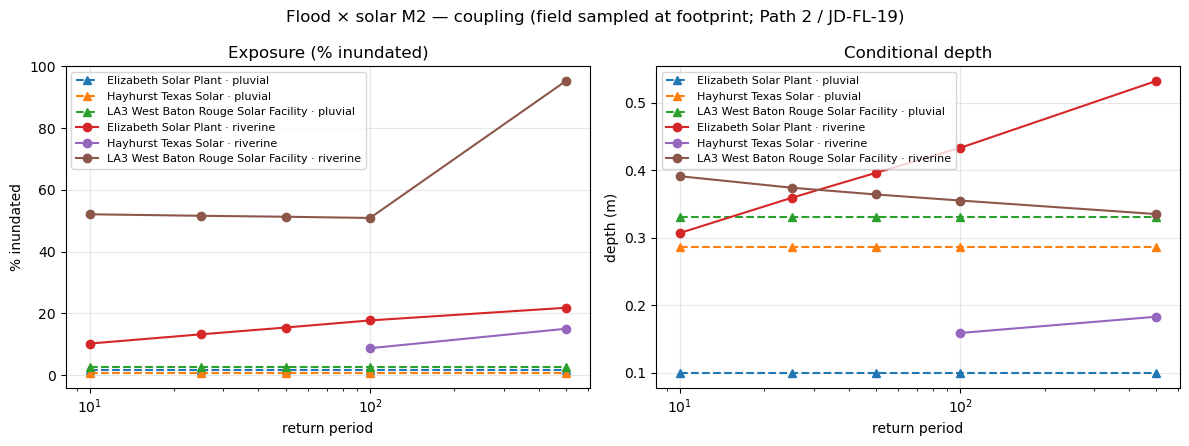

✓ riverine Elizabeth Solar Plant: exposure×depth 100yr=0.0766 → 500yr=0.1160 m (grows, full-res)
✓ coastal Discovery Solar Center: 117 storms, Cat-5 footprint surge 12.4 ft
✓ coastal LA3 West Baton Rouge Solar Facility: 11 storms, Cat-5 footprint surge 14.5 ft
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m2_coupling_manifest.json


In [5]:
import matplotlib.pyplot as plt
fig, (axE, axD) = plt.subplots(1, 2, figsize=(12, 4.5))
for (sp, nm), g in coup.groupby(["sub_peril", "name"]):
    g = g.sort_values("rp_years"); ls = "o-" if sp == "riverine" else "^--"
    axE.plot(g["rp_years"].to_numpy(), (g["exposure_fraction"]*100).to_numpy(), ls, label=f"{nm} · {sp}")
    axD.plot(g["rp_years"].to_numpy(), g["conditional_depth_m"].to_numpy(), ls, label=f"{nm} · {sp}")
for ax, ttl, yl in [(axE, "Exposure (% inundated)", "% inundated"), (axD, "Conditional depth", "depth (m)")]:
    ax.set_xscale("log"); ax.set_xlabel("return period"); ax.set_ylabel(yl); ax.set_title(ttl); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Flood × solar M2 — coupling (field sampled at footprint; Path 2 / JD-FL-19)")
fig.tight_layout()
plt.show()


def ed(df, nm, rp, sp="riverine"):
    r = df[(df.name == nm) & (df.rp_years == rp) & (df.sub_peril == sp)].iloc[0]
    return r["exposure_fraction"] * r["conditional_depth_m"]
HIGH, LOW = "Elizabeth Solar Plant", "Hayhurst Texas Solar"
assert ed(coup, HIGH, 500) >= ed(coup, HIGH, 100) > 0, "riverine high site should grow 100->500yr"
assert ed(coup, HIGH, 500) / max(ed(coup, LOW, 500), 1e-9) > 3, "riverine high site should dominate the baseline"
print(f"✓ riverine {HIGH}: exposure×depth 100yr={ed(coup,HIGH,100):.4f} → 500yr={ed(coup,HIGH,500):.4f} m (grows, full-res)")
for cs in coastal_summ:
    print(f"✓ coastal {cs['name']}: {cs['n_storms']} storms, Cat-5 footprint surge {cs['depth_by_cat'][5]['mean_ft']:.1f} ft")

manifest = {
    "peril": "flood", "sub_peril": ["riverine", "pluvial", "coastal"], "event_family_id": None, "layer": "M2",
    "coupling_type": "site_conditioned (bucket 3) — Path 2 (JD-FL-19). UNIFIED M2 (JD-FL-17, LA3 all-three site): "
                     "riverine = areal sampling of the M1 depth field at full resolution (JD-FL-18), pluvial = lidar "
                     "ponding over the runoff field (RP frame); coastal = areal SLOSH surge per storm (event frame).",
    "contract": {"exposure_fraction": "areal inundated fraction of footprint (field masked to polygon)",
                 "conditional_depth_m": "inundated-cell mean depth GIVEN flooded",
                 "deferred_to_M3": "per-subsystem height conditioning + fragility"},
    "rp_rows": json.loads(coup.to_json(orient="records")),                          # riverine + pluvial (RP-indexed)
    "coastal_sites": [{"name": cs["name"], "slug": cs["slug"], "n_storms": cs["n_storms"],
                       "slosh_depth_by_cat_ft": cs["depth_by_cat"]} for cs in coastal_summ],  # per-storm parquets keyed by slug
    "coastal_depth_source": COASTAL_DEPTH_SOURCE,
    "rows": json.loads(coup.to_json(orient="records")),                             # back-compat alias (= rp_rows)
}
(OUT / "flood_solar_m2_coupling_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_solar_m2_coupling_manifest.json")